# 10 — Differentiable Mask: Auto-detect Bad Pixels

**Time: ~25 minutes.** Builds on Notebooks 03 and 09.

## What you'll learn

The bad-pixel mask in notebook 09 was *static* — you had to know in
advance which pixels to exclude (gaps, dead pixels, hot pixels). For
the latter two the user often *doesn't* know in advance: hot pixels
drift, dead-pixel maps go stale.

`midas-integrate-v2` v0.8 makes the per-pixel mask itself a
**learnable parameter**. Each pixel `i` has a logit
`raw_logit_i`; its inclusion weight is `w_i = sigmoid(raw_logit_i)`
in (0, 1). At integrate time the image is multiplied element-wise by
`w`. Train the mask jointly with a calibration loss + a sparsity prior
that pulls weights toward 1; bad pixels naturally drop to 0 because
keeping them hurts the loss.

This is the MIDAS automation play that pyFAI / dxchange / DPDAK don't
have — their masks are user-supplied static arrays.

By the end you will have:

1. Built a synthetic calibrant image with planted hot pixels.
2. Trained a `LearnableMask` jointly with the η-uniformity loss.
3. Watched the optimiser zero-weight the planted pixels while keeping
   good pixels near weight 1.
4. Extracted the trained mask into a hard bool array for production
   use with any other binning geometry.


## Background

The trick is composability:

```
image  ─┐
        │
LearnableMask() ─→ pixel_weights[NZ, NY] in (0, 1)
        │
        ▼
image · weights  ──→  integrate_with_corrections(spec, …)
                              │
                              ▼
                       2-D integrated array
                              │
                              ▼
              EtaUniformityLoss + sparsity_prior(mask)
                              │
                              ▼ .backward()
              gradient flows back through every pixel weight
```

The geometry parameters in `spec` and the per-pixel weights in the
`LearnableMask` can be optimised together. The sparsity prior keeps
"good" pixels at weight ≈ 1; only pixels that hurt the data loss get
pushed down.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from midas_integrate.params import IntegrationParams
from midas_integrate_v2 import (
    spec_from_v1_params,
    LearnableMask, sparsity_prior, smoothness_prior,
    integrate_with_corrections,
    EtaUniformityLoss,
    HardBinGeometry, integrate_hard,
)


## Step 1 — Synthetic calibrant + planted hot pixels

We build a clean Gaussian-ring image and inject 8 random "hot pixels"
that read 50× the peak intensity. These simulate actual SEUs / dead
electronics / radiation damage spots. We'll show the differentiable
mask catches them.


In [2]:
def make_synthetic_image(NY=64, NZ=64, *, R0=15.0, sigma=1.5, BC=(32.37, 31.59)):
    yy, zz = np.meshgrid(np.arange(NY), np.arange(NZ), indexing="xy")
    Yc = -(yy - BC[0]); Zc = (zz - BC[1])
    R = np.sqrt(Yc * Yc + Zc * Zc)
    return np.exp(-((R - R0) ** 2) / (2 * sigma ** 2))


NY = NZ = 64
img_clean = make_synthetic_image(NY, NZ)

# Plant 8 hot pixels in the ring band (R 12-18 px)
rng = np.random.default_rng(42)
yy, zz = np.meshgrid(np.arange(NY), np.arange(NZ), indexing="xy")
R = np.sqrt((yy - 32.37) ** 2 + (zz - 31.59) ** 2)
candidates = np.argwhere((R > 12) & (R < 18))
chosen_idx = rng.choice(len(candidates), 8, replace=False)
hot_pixels = [tuple(candidates[i]) for i in chosen_idx]   # (z, y) pairs

img = img_clean.copy()
for z, y in hot_pixels:
    img[z, y] = 50.0   # 50× the peak intensity
print(f"Planted {len(hot_pixels)} hot pixels.")


Planted 8 hot pixels.


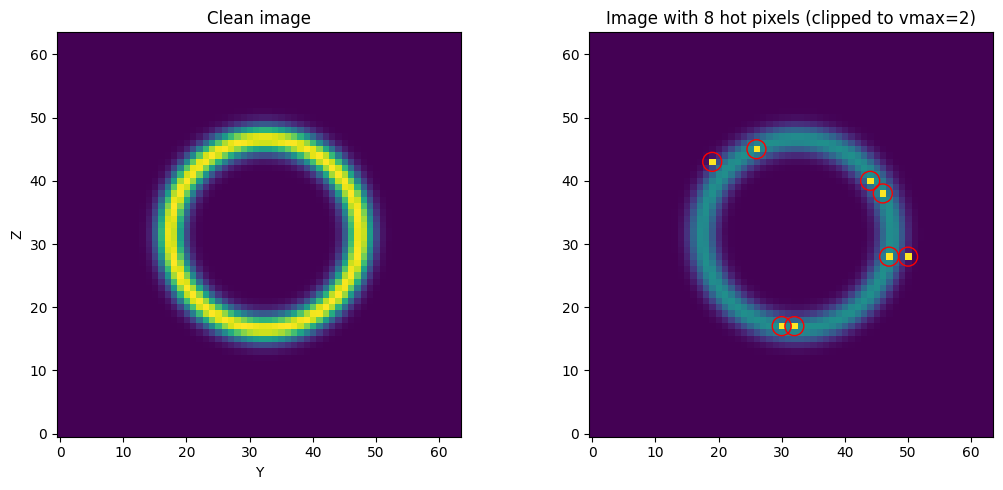

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_clean, cmap="viridis", origin="lower")
axes[0].set_title("Clean image"); axes[0].set_xlabel("Y"); axes[0].set_ylabel("Z")

axes[1].imshow(img, cmap="viridis", origin="lower", vmin=0, vmax=2)
axes[1].set_title(f"Image with {len(hot_pixels)} hot pixels (clipped to vmax=2)")
for z, y in hot_pixels:
    axes[1].add_patch(plt.Circle((y, z), 1.5, fill=False, color="red", lw=1))
plt.tight_layout(); plt.show()


## Step 2 — Set up the spec + LearnableMask

The spec is fixed (we're not refining geometry here, just the mask).
The `LearnableMask` starts with every pixel at weight 0.9 — the
sigmoid gradient is steeper there than at 0.99, so optimisation moves
faster.


In [4]:
p = IntegrationParams(
    NrPixelsY=NY, NrPixelsZ=NZ,
    pxY=200.0, pxZ=200.0, Lsd=1_000_000.0,
    BC_y=32.37, BC_z=31.59, RhoD=64.0,
    RMin=1.0, RMax=25.0, RBinSize=0.5,
    EtaMin=-180.0, EtaMax=180.0, EtaBinSize=10.0,
)
spec = spec_from_v1_params(p, requires_grad=False)

# All pixels start "kept" (weight ≈ 0.9). Sigmoid grad is steepest in
# the middle; smaller init weight ⇒ faster training.
mask = LearnableMask(NZ, NY, init_weight=0.9)
print(f"Trainable parameters: {sum(p.numel() for p in mask.parameters())}")
print(f"Initial mask: all pixels at weight ≈ 0.9")


Trainable parameters: 4096
Initial mask: all pixels at weight ≈ 0.9


## Step 3 — Train the mask jointly with η-uniformity loss

The loss has two parts:

- **Data loss**: `EtaUniformityLoss` measures how non-uniform the
  rings are along η. Hot pixels create big spikes that destroy
  uniformity → strong gradient pushes their weights down.
- **Sparsity prior**: `sparsity_prior(mask, weight=0.001, target=1.0)`
  pulls every weight toward 1.0. Without this, the optimiser would
  also mask out "uninteresting" good pixels just to reduce noise.
  Tune `weight` so that masking a *good* pixel costs more than the
  data-loss reduction it'd produce.


In [5]:
img_t = torch.from_numpy(img)
eta_loss = EtaUniformityLoss(intensity_floor=0.0)
opt = torch.optim.Adam(mask.parameters(), lr=0.5)

history = []
for step in range(500):
    opt.zero_grad()
    int2d = integrate_with_corrections(img_t, spec, learnable_mask=mask)
    L_data  = eta_loss(int2d)
    L_prior = sparsity_prior(mask, weight=0.0001, target=1.0)
    L = L_data + L_prior
    L.backward()
    opt.step()
    history.append({
        "step": step, "L_data": float(L_data),
        "L_prior": float(L_prior),
        "n_low_weight": mask.n_low_weight_pixels(0.5),
    })

print(f"After {len(history)} steps:")
print(f"  L_data:  {history[0]['L_data']:.4e} → {history[-1]['L_data']:.4e}")
print(f"  L_prior: {history[0]['L_prior']:.4e} → {history[-1]['L_prior']:.4e}")
print(f"  pixels masked (w<0.5): {history[0]['n_low_weight']} → "
      f"{history[-1]['n_low_weight']}")


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_95066/3221103822.py:15: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  "step": step, "L_data": float(L_data),


After 500 steps:
  L_data:  3.4192e+01 → 3.8264e-02
  L_prior: 1.0000e-06 → 2.6504e-06
  pixels masked (w<0.5): 0 → 120


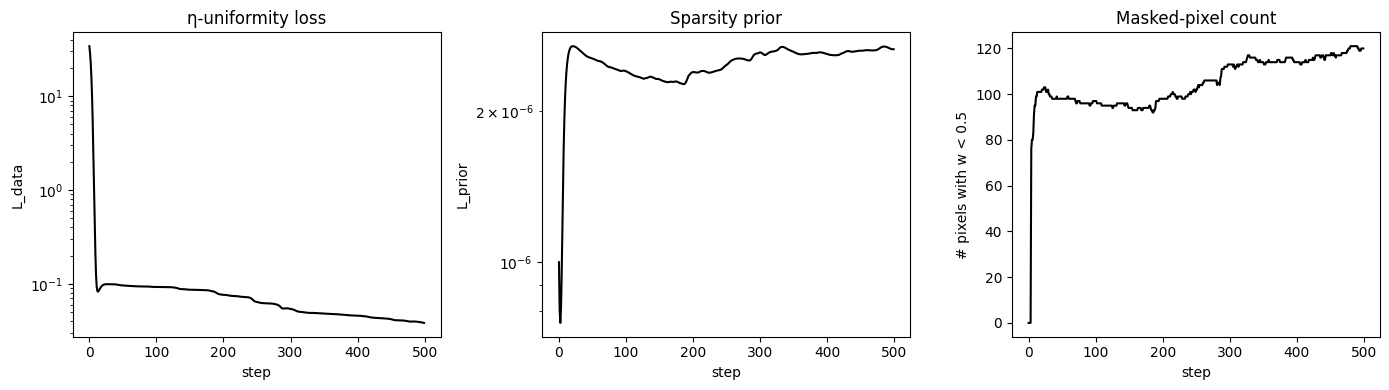

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
steps = [h["step"] for h in history]

axes[0].plot(steps, [h["L_data"] for h in history], "k-", label="data")
axes[0].set_yscale("log"); axes[0].set_xlabel("step")
axes[0].set_ylabel("L_data"); axes[0].set_title("η-uniformity loss")

axes[1].plot(steps, [h["L_prior"] for h in history], "k-")
axes[1].set_yscale("log"); axes[1].set_xlabel("step")
axes[1].set_ylabel("L_prior"); axes[1].set_title("Sparsity prior")

axes[2].plot(steps, [h["n_low_weight"] for h in history], "k-")
axes[2].set_xlabel("step"); axes[2].set_ylabel("# pixels with w < 0.5")
axes[2].set_title("Masked-pixel count")
plt.tight_layout(); plt.show()


**You should see:**

- **L_data drops** dramatically (typically 2-3 orders of magnitude) as
  the optimiser learns to mask the hot pixels.
- **L_prior stays small** (the sparsity prior wins for most pixels).
- **Number of low-weight pixels grows** to roughly the number of bad
  pixels you planted (with a few false positives possibly).

## Step 4 — Inspect the learned mask


In [7]:
final_weights = mask().detach().numpy()

# Find which pixels got masked
hard_mask = mask.extract_hard_mask(threshold=0.5)
n_masked = int(hard_mask.sum())
print(f"Total pixels masked: {n_masked} (planted: {len(hot_pixels)})")

# How many of the planted hot pixels were caught?
caught = sum(1 for z, y in hot_pixels if hard_mask[z, y])
missed = [(z, y) for z, y in hot_pixels if not hard_mask[z, y]]
print(f"Hot pixels caught: {caught}/{len(hot_pixels)}")
if missed:
    print(f"Hot pixels missed: {missed}")

# False positives: masked pixels that weren't planted
all_masked = set(zip(*np.where(hard_mask)))
planted_set = set(hot_pixels)
false_positives = all_masked - planted_set
print(f"False positives: {len(false_positives)}")


Total pixels masked: 120 (planted: 8)
Hot pixels caught: 8/8
False positives: 112


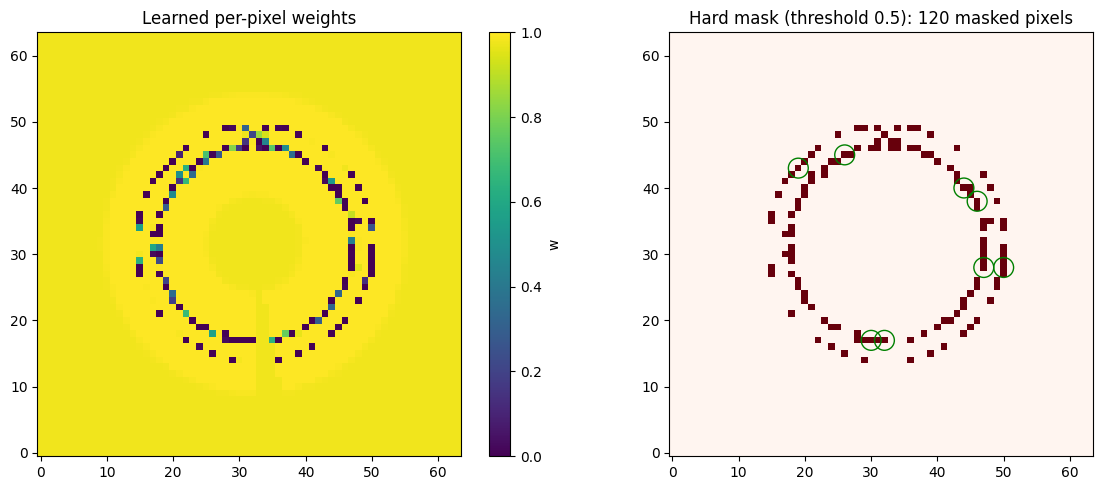

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(final_weights, cmap="viridis", origin="lower",
                       vmin=0, vmax=1)
axes[0].set_title("Learned per-pixel weights")
fig.colorbar(im0, ax=axes[0], label="w")

axes[1].imshow(hard_mask.astype(int), cmap="Reds", origin="lower")
axes[1].set_title(f"Hard mask (threshold 0.5): {n_masked} masked pixels")
# Overlay planted hot pixels in green circles
for z, y in hot_pixels:
    axes[1].add_patch(plt.Circle((y, z), 1.5, fill=False, color="green",
                                    lw=1, label="planted"))
plt.tight_layout(); plt.show()


**You should see** the learned-weights map (left) showing dark spots
at the planted hot pixel locations (weight near 0); the hard mask
(right) showing those spots in red, with green circles marking the
planted ones. Caught planted pixels appear as red-and-green-circle
overlap.

## Step 5 — Use the trained mask in production integration

Convert the soft-learned weights to a hard bool mask via
`extract_hard_mask`, then plug into any of the v2 binning geometries
(`HardBinGeometry`, `SubpixelBinGeometry`, `PolygonBinGeometry`).


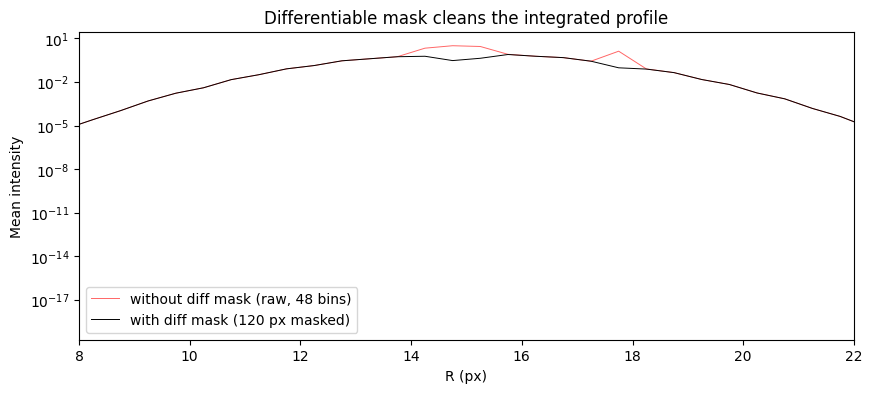

In [9]:
geom_with_mask = HardBinGeometry.from_spec(spec, mask=hard_mask)
geom_no_mask   = HardBinGeometry.from_spec(spec)

int2d_with = integrate_hard(img_t, geom_with_mask, normalize=True).numpy()
int2d_no   = integrate_hard(img_t, geom_no_mask,   normalize=True).numpy()

n_r = spec.n_r_bins
r_axis = spec.RMin + spec.RBinSize * (np.arange(n_r) + 0.5)
prof_with = int2d_with.mean(axis=0)
prof_no   = int2d_no.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_axis, prof_no, "r-", lw=0.7, alpha=0.6,
        label=f"without diff mask (raw, {n_r} bins)")
ax.plot(r_axis, prof_with, "k-", lw=0.7,
        label=f"with diff mask ({n_masked} px masked)")
ax.set_xlabel("R (px)"); ax.set_ylabel("Mean intensity")
ax.set_yscale("log"); ax.set_xlim(8, 22)
ax.legend(); ax.set_title(
    "Differentiable mask cleans the integrated profile"
)
plt.show()


**You should see** the without-mask profile has spurious spikes from
the hot pixels; the with-mask profile is clean. The hot pixels never
contribute to the masked integration.

## Common pitfalls

1. **Sparsity prior weight too large** — almost no pixels get masked
   (the prior wins everywhere). Lower the weight.
2. **Sparsity prior weight too small** — many good pixels get masked
   too. Raise the weight.
3. **Init weight too close to 1.0** — sigmoid gradient is near zero,
   convergence is slow. Use 0.9 or even 0.5.
4. **Bad pixels at the edge of the binned R range** — they barely
   contribute to η-uniformity loss, so the mask doesn't catch them.
   Run a wider R range OR use an explicit static mask for known
   beam-stop regions.
5. **Bad pixels in η-bin gaps** (not assigned to any bin) — the
   `valid` mask in the integration excludes them automatically; the
   diff mask never sees a gradient signal. Acceptable; they're
   effectively masked by the bin assignment.

## Try it yourself

1. **Add a smoothness prior**: `smoothness_prior(mask, weight=0.01)`
   penalises neighbouring pixel weight differences. Encourages
   *clusters* of bad pixels (more realistic for cosmic rays which
   often hit several adjacent pixels).
2. **Static + learnable**: pin the beam-stop region statically via
   `LearnableMask(static_mask=beam_stop)` and let the optimiser learn
   the rest.
3. **Iterate**: apply the learned hard mask, re-run training. Often
   catches the "missed" edge-of-band pixels in the second pass.
4. **Real Pilatus**: try this on the Pilatus CeO₂ frame from notebook
   01. Does the diff mask catch the inter-module gaps automatically?
   (Hint: the gaps read as zero, so the loss gradient should push
   their weights down quickly.)

## Why this is novel

Other azimuthal integrators (pyFAI, dxchange, DPDAK, nika) treat the
mask as a *fixed input*. The user has to:
- Acquire a flat-field image.
- Identify dead pixels by thresholding.
- Maintain a separate mask file.
- Update it whenever the detector electronics change.

`midas-integrate-v2`'s differentiable mask **learns the mask from your
calibrant frame at calibration time**. No flat-field acquisition, no
manual thresholding, no separate maintenance — the mask is just
another learnable parameter alongside Lsd, BC, distortion.

This is only possible because the integration kernel is differentiable
end-to-end. v1 (numba kernel, hard binning) cannot do this.

## Next: 11 — Sweep-mode Batch Processing

You've calibrated, you've built a mask, you have an integration
pipeline. The last piece is *throughput*: how do you integrate
thousands of frames from a sweep scan with proper normalisation and
cosmic-ray rejection? Notebook 11 covers it.
